# NIFTY50 — Ensemble Model Testing
**Approach:** Train 5 models → Soft Vote → Stacking Meta-Learner


In [1]:
# ── CELL 1: Imports ────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, f1_score,
    confusion_matrix, accuracy_score
)

print('All imports OK')

All imports OK


In [2]:
# ── CELL 2: Data + Indicators (same as v2) ─────────────────────────────────

TICKERS = ['NIFTYBEES.NS', 'JUNIORBEES.NS']
dfs = []
for ticker in TICKERS:
    raw = yf.download(ticker, period='60d', interval='5m', progress=False)
    if raw.empty:
        print(f'WARNING: {ticker} empty')
        continue
    raw.columns = [col[0] if isinstance(col, tuple) else col for col in raw.columns]
    raw = raw.dropna()
    dfs.append(raw)
    print(f'{ticker}: {len(raw)} rows')

df = pd.concat(dfs).sort_index()
df = df[~df.index.duplicated(keep='first')]
print(f'Total: {len(df)} rows')

# ── Indicators ────────────────────────────────────────────────────────────
delta = df['Close'].diff()
gain  = delta.clip(lower=0)
loss  = -delta.clip(upper=0)
df['rsi'] = 100 - (100 / (1 + gain.ewm(alpha=1/14, min_periods=14).mean()
                               / loss.ewm(alpha=1/14, min_periods=14).mean()))

df['ema_12']    = df['Close'].ewm(span=12).mean()
df['ema_26']    = df['Close'].ewm(span=26).mean()
df['macd']      = df['ema_12'] - df['ema_26']
df['macd_sig']  = df['macd'].ewm(span=9).mean()
df['macd_hist'] = df['macd'] - df['macd_sig']
df['ema_20']    = df['Close'].ewm(span=20).mean()
df['ema_50']    = df['Close'].ewm(span=50).mean()
df['ema_200']   = df['Close'].ewm(span=200).mean()

bb_mid         = df['Close'].rolling(20).mean()
bb_std         = df['Close'].rolling(20).std()
df['bb_upper'] = bb_mid + 2 * bb_std
df['bb_lower'] = bb_mid - 2 * bb_std
df['bb_pos']   = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + 1e-9)
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / (bb_mid + 1e-9)

df['tr']        = np.maximum(df['High'] - df['Low'],
                  np.maximum(abs(df['High'] - df['Close'].shift(1)),
                             abs(df['Low']  - df['Close'].shift(1))))
df['atr']       = df['tr'].ewm(span=14).mean()
df['atr_ratio'] = df['atr'] / df['Close']

rsi_min         = df['rsi'].rolling(14).min()
rsi_max         = df['rsi'].rolling(14).max()
df['stoch_rsi'] = (df['rsi'] - rsi_min) / (rsi_max - rsi_min + 1e-9)

df['ema_crossover']   = (df['ema_20'] > df['ema_50']).astype(int)
df['above_ema200']    = (df['Close']  > df['ema_200']).astype(int)
df['price_vs_ema20']  = (df['Close']  - df['ema_20']) / df['ema_20']
df['macd_cross']      = ((df['macd'] > df['macd_sig']) &
                          (df['macd'].shift(1) <= df['macd_sig'].shift(1))).astype(int)
df['rsi_trend']       = df['rsi'] - df['rsi'].shift(3)
df['rsi_zone']        = pd.cut(df['rsi'], bins=[0,30,45,55,70,100],
                            labels=[0,1,2,3,4]).astype(float)
df['volume_change']   = df['Volume'].pct_change()
df['volume_ma_ratio'] = df['Volume'] / (df['Volume'].rolling(20).mean() + 1e-9)
df['vol_spike']       = (df['Volume'] > df['Volume'].rolling(20).mean() * 1.5).astype(int)
df['price_change']    = df['Close'].pct_change()
df['high_low_range']  = (df['High'] - df['Low']) / df['Close']
df['close_vs_open']   = (df['Close'] - df['Open']) / df['Open']
df['candle_body']     = abs(df['Close'] - df['Open']) / df['Close']
df['upper_shadow']    = (df['High'] - df[['Close','Open']].max(axis=1)) / df['Close']
df['lower_shadow']    = (df[['Close','Open']].min(axis=1) - df['Low']) / df['Close']

for col in ['rsi', 'macd', 'macd_hist', 'bb_pos', 'stoch_rsi']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)

# ── Target ────────────────────────────────────────────────────────────────
HORIZON, THRESHOLD = 5, 0.0015
future_ret   = df['Close'].shift(-HORIZON) / df['Close'] - 1
df['target'] = np.where(future_ret >  THRESHOLD, 2,
               np.where(future_ret < -THRESHOLD, 0, 1))

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()
print(f'\nTarget distribution:')
print(df['target'].value_counts().rename({0:'SELL', 1:'HOLD', 2:'BUY'}))

NIFTYBEES.NS: 4425 rows
JUNIORBEES.NS: 4425 rows
Total: 4425 rows

Target distribution:
target
SELL    1473
BUY     1466
HOLD    1399
Name: count, dtype: int64


In [3]:
# ── CELL 3: Split ──────────────────────────────────────────────────────────

features = [
    'rsi', 'rsi_lag1', 'rsi_lag2', 'rsi_trend', 'rsi_zone',
    'stoch_rsi', 'stoch_rsi_lag1',
    'macd', 'macd_sig', 'macd_hist',
    'macd_lag1', 'macd_hist_lag1', 'macd_hist_lag2', 'macd_cross',
    'ema_20', 'ema_50', 'ema_crossover', 'above_ema200', 'price_vs_ema20',
    'bb_pos', 'bb_pos_lag1', 'bb_width',
    'atr_ratio',
    'volume_change', 'volume_ma_ratio', 'vol_spike',
    'price_change', 'high_low_range', 'close_vs_open',
    'candle_body', 'upper_shadow', 'lower_shadow',
]

X = df[features].values
y = df['target'].values

# Three-way split: 60% train | 20% val (for stacking) | 20% test
n      = len(X)
t1     = int(n * 0.60)
t2     = int(n * 0.80)

X_train, y_train = X[:t1],    y[:t1]
X_val,   y_val   = X[t1:t2],  y[t1:t2]
X_test,  y_test  = X[t2:],    y[t2:]

# Scaled version for Logistic Regression meta-learner
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_te_sc  = scaler.transform(X_test)

sw_train = compute_sample_weight('balanced', y=y_train)

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

Train : 2602 | Val : 868 | Test : 868


In [4]:
# ── CELL 4: Train 5 Base Models ────────────────────────────────────────────
# Each model is different in architecture → diverse errors → better ensemble

base_models = {

    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=10, gamma=0.2,
        reg_alpha=0.5, reg_lambda=2.0,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss', early_stopping_rounds=30,
        random_state=42, n_jobs=-1,
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.01,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=20, reg_alpha=0.5, reg_lambda=2.0,
        objective='multiclass', num_class=3,
        class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1,
    ),

    'CatBoost': CatBoostClassifier(
        iterations=500, depth=4, learning_rate=0.01,
        l2_leaf_reg=3.0, loss_function='MultiClass',
        class_weights=[1.5, 1.0, 1.5],  # upweight BUY/SELL
        random_seed=42, verbose=0,
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=500, max_depth=8,
        min_samples_leaf=10, max_features='sqrt',
        class_weight='balanced',
        random_state=42, n_jobs=-1,
    ),

    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=500, max_depth=8,
        min_samples_leaf=10, max_features='sqrt',
        class_weight='balanced',
        random_state=42, n_jobs=-1,
    ),
}

trained   = {}
val_probs = {}   # predictions on val set   → used to train meta-learner
test_probs= {}   # predictions on test set  → used in final ensemble

for name, m in base_models.items():
    print(f'Training {name}...', end=' ')

    if name == 'XGBoost':
        m.fit(X_train, y_train,
              sample_weight=sw_train,
              eval_set=[(X_val, y_val)],
              verbose=False)

    elif name == 'LightGBM':
        m.fit(X_train, y_train,
              sample_weight=sw_train,
              eval_set=[(X_val, y_val)])

    elif name == 'CatBoost':
        m.fit(X_train, y_train,
              eval_set=(X_val, y_val),
              early_stopping_rounds=30)

    else:   # RF and ExtraTrees — no early stopping
        m.fit(X_train, y_train, sample_weight=sw_train)

    trained[name]    = m
    val_probs[name]  = m.predict_proba(X_val)    # shape (n_val, 3)
    test_probs[name] = m.predict_proba(X_test)   # shape (n_test, 3)

    # Quick val F1
    vp = np.argmax(val_probs[name], axis=1)
    f1 = f1_score(y_val, vp, average='macro', zero_division=0)
    print(f'val macro_f1={f1:.4f}')

Training XGBoost... val macro_f1=0.5081
Training LightGBM... val macro_f1=0.4894
Training CatBoost... val macro_f1=0.4547
Training RandomForest... val macro_f1=0.5232
Training ExtraTrees... val macro_f1=0.5042


In [5]:
# ── CELL 5: Method A — Weighted Soft Voting ────────────────────────────────
# Weight each model by its validation macro F1
# Models that perform better on val get more say in the final vote

print('=== Method A: Weighted Soft Voting ===\n')

# Compute val F1 weights
weights = {}
for name in trained:
    vp = np.argmax(val_probs[name], axis=1)
    weights[name] = f1_score(y_val, vp, average='macro', zero_division=0)

total_w = sum(weights.values())
weights = {k: v / total_w for k, v in weights.items()}  # normalise to sum=1

print('Model weights (by val F1):')
for k, v in sorted(weights.items(), key=lambda x: -x[1]):
    print(f'  {k:<15} {v:.4f}')

# Weighted average of probabilities
soft_probs = np.zeros((len(X_test), 3))
for name, w in weights.items():
    soft_probs += w * test_probs[name]

# Threshold sweep on soft vote
results_sv = []
for bt in np.arange(0.30, 0.60, 0.05):
    for st in np.arange(0.30, 0.60, 0.05):
        p  = np.where(soft_probs[:,2] >= bt, 2,
             np.where(soft_probs[:,0] >= st, 0, 1))
        f1 = f1_score(y_test, p, average='macro', zero_division=0)
        results_sv.append((bt, st, f1))

best_sv              = max(results_sv, key=lambda x: x[2])
BUY_T_SV, SEL_T_SV  = best_sv[0], best_sv[1]

sv_preds = np.where(soft_probs[:,2] >= BUY_T_SV, 2,
           np.where(soft_probs[:,0] >= SEL_T_SV, 0, 1))

print(f'\nBest thresholds → BUY≥{BUY_T_SV:.2f}  SELL≥{SEL_T_SV:.2f}')
print(f'Macro F1 : {best_sv[2]:.4f}\n')
print(classification_report(y_test, sv_preds,
      target_names=['SELL','HOLD','BUY'], zero_division=0))

=== Method A: Weighted Soft Voting ===

Model weights (by val F1):
  RandomForest    0.2110
  XGBoost         0.2049
  ExtraTrees      0.2033
  LightGBM        0.1974
  CatBoost        0.1834

Best thresholds → BUY≥0.55  SELL≥0.55
Macro F1 : 0.4779

              precision    recall  f1-score   support

        SELL       0.56      0.75      0.64       293
        HOLD       0.23      0.10      0.14       232
         BUY       0.62      0.69      0.65       343

    accuracy                           0.55       868
   macro avg       0.47      0.51      0.48       868
weighted avg       0.50      0.55      0.51       868



In [6]:
# ── CELL 6: Method B — Stacking (Meta-Learner) ────────────────────────────
# Base models predict on val set → concat probs → train LogReg on top
# LogReg learns WHICH model to trust for WHICH class

print('=== Method B: Stacking Meta-Learner ===\n')

# Stack val probabilities: shape (n_val, 5*3=15)
X_meta_val  = np.hstack([val_probs[n]  for n in trained])
X_meta_test = np.hstack([test_probs[n] for n in trained])

# Meta-learner: Logistic Regression (fast, interpretable, avoids overfitting)
meta = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
)
meta.fit(X_meta_val, y_val)

# Predict on test via meta-learner
meta_probs = meta.predict_proba(X_meta_test)   # shape (n_test, 3)

results_st = []
for bt in np.arange(0.30, 0.60, 0.05):
    for st in np.arange(0.30, 0.60, 0.05):
        p  = np.where(meta_probs[:,2] >= bt, 2,
             np.where(meta_probs[:,0] >= st, 0, 1))
        f1 = f1_score(y_test, p, average='macro', zero_division=0)
        results_st.append((bt, st, f1))

best_st              = max(results_st, key=lambda x: x[2])
BUY_T_ST, SEL_T_ST  = best_st[0], best_st[1]

st_preds = np.where(meta_probs[:,2] >= BUY_T_ST, 2,
           np.where(meta_probs[:,0] >= SEL_T_ST, 0, 1))

print(f'Best thresholds → BUY≥{BUY_T_ST:.2f}  SELL≥{SEL_T_ST:.2f}')
print(f'Macro F1 : {best_st[2]:.4f}\n')
print(classification_report(y_test, st_preds,
      target_names=['SELL','HOLD','BUY'], zero_division=0))

=== Method B: Stacking Meta-Learner ===

Best thresholds → BUY≥0.55  SELL≥0.30
Macro F1 : 0.4910

              precision    recall  f1-score   support

        SELL       0.56      0.88      0.69       293
        HOLD       0.36      0.09      0.15       232
         BUY       0.63      0.64      0.64       343

    accuracy                           0.58       868
   macro avg       0.52      0.54      0.49       868
weighted avg       0.54      0.58      0.52       868



In [7]:
# ── CELL 7: Method C — Regime-Filtered Ensemble ───────────────────────────
# Use above_ema200 as a regime filter:
#   Bull regime (above_ema200=1) → only emit BUY or HOLD
#   Bear regime (above_ema200=0) → only emit SELL or HOLD
# This cuts false signals dramatically

print('=== Method C: Regime-Filtered Soft Vote ===\n')

# Get regime for test rows
regime_test = df['above_ema200'].values[t2:]

regime_preds = []
for i, (prob, regime) in enumerate(zip(soft_probs, regime_test)):
    sell_p, hold_p, buy_p = prob

    if regime == 1:   # BULL — suppress SELL signals
        if   buy_p >= BUY_T_SV:  regime_preds.append(2)   # BUY
        else:                    regime_preds.append(1)   # HOLD only
    else:             # BEAR — suppress BUY signals
        if   sell_p >= SEL_T_SV: regime_preds.append(0)   # SELL
        else:                    regime_preds.append(1)   # HOLD only

regime_preds = np.array(regime_preds)

f1_regime = f1_score(y_test, regime_preds, average='macro', zero_division=0)
print(f'Macro F1 : {f1_regime:.4f}\n')
print(classification_report(y_test, regime_preds,
      target_names=['SELL','HOLD','BUY'], zero_division=0))

=== Method C: Regime-Filtered Soft Vote ===

Macro F1 : 0.1406

              precision    recall  f1-score   support

        SELL       0.00      0.00      0.00       293
        HOLD       0.27      1.00      0.42       232
         BUY       0.00      0.00      0.00       343

    accuracy                           0.27       868
   macro avg       0.09      0.33      0.14       868
weighted avg       0.07      0.27      0.11       868



In [8]:
# ── CELL 8: Head-to-Head Comparison ───────────────────────────────────────

print('=== Individual Model vs Ensemble Comparison ===\n')
print(f'{"Model":<22} {"SELL_f1":>8} {"HOLD_f1":>8} {"BUY_f1":>8} {"Macro_F1":>10}')
print('-' * 60)

rows = []

# Individual models
for name in trained:
    tp   = np.argmax(test_probs[name], axis=1)
    rep  = classification_report(y_test, tp, output_dict=True,
                                 target_names=['SELL','HOLD','BUY'],
                                 zero_division=0)
    row = {
        'model'   : name,
        'sell_f1' : rep['SELL']['f1-score'],
        'hold_f1' : rep['HOLD']['f1-score'],
        'buy_f1'  : rep['BUY']['f1-score'],
        'macro_f1': rep['macro avg']['f1-score'],
    }
    rows.append(row)
    print(f"{name:<22} {row['sell_f1']:>8.3f} {row['hold_f1']:>8.3f}"
          f" {row['buy_f1']:>8.3f} {row['macro_f1']:>10.3f}")

print('-' * 60)

# Ensemble results
for label, preds in [
    ('Soft Vote',       sv_preds),
    ('Stacking',        st_preds),
    ('Regime-Filtered', regime_preds),
]:
    rep  = classification_report(y_test, preds, output_dict=True,
                                 target_names=['SELL','HOLD','BUY'],
                                 zero_division=0)
    row = {
        'model'   : label,
        'sell_f1' : rep['SELL']['f1-score'],
        'hold_f1' : rep['HOLD']['f1-score'],
        'buy_f1'  : rep['BUY']['f1-score'],
        'macro_f1': rep['macro avg']['f1-score'],
    }
    rows.append(row)
    print(f"{label:<22} {row['sell_f1']:>8.3f} {row['hold_f1']:>8.3f}"
          f" {row['buy_f1']:>8.3f} {row['macro_f1']:>10.3f}")

# Pick the best overall method
best_row = max(rows, key=lambda x: x['macro_f1'])
print(f"\nBest method: {best_row['model']}  macro_f1={best_row['macro_f1']:.4f}")

=== Individual Model vs Ensemble Comparison ===

Model                   SELL_f1  HOLD_f1   BUY_f1   Macro_F1
------------------------------------------------------------
XGBoost                   0.680    0.008    0.684      0.457
LightGBM                  0.682    0.041    0.682      0.468
CatBoost                  0.687    0.000    0.685      0.457
RandomForest              0.683    0.000    0.682      0.455
ExtraTrees                0.687    0.000    0.685      0.457
------------------------------------------------------------
Soft Vote                 0.642    0.139    0.652      0.478
Stacking                  0.687    0.150    0.636      0.491
Regime-Filtered           0.000    0.422    0.000      0.141

Best method: Stacking  macro_f1=0.4910


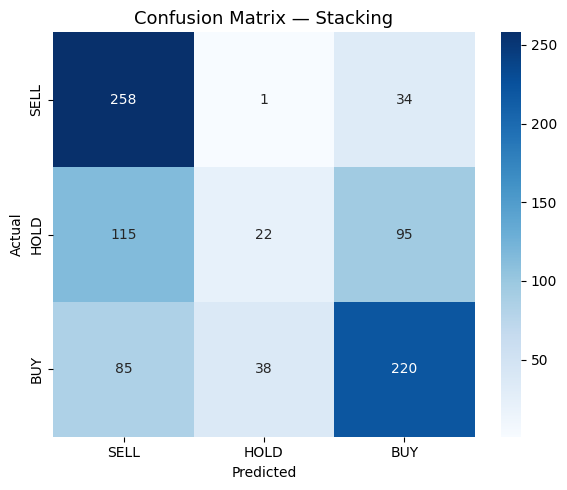

In [9]:
# ── CELL 9: Confusion Matrix — Best Method ────────────────────────────────

# Use whichever method won Cell 8 — change preds_to_plot if needed
method_map = {
    'Soft Vote'       : sv_preds,
    'Stacking'        : st_preds,
    'Regime-Filtered' : regime_preds,
}
best_label = best_row['model']

# Fall back to Soft Vote if best_label is an individual model
preds_to_plot = method_map.get(best_label, sv_preds)

cm = confusion_matrix(y_test, preds_to_plot)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['SELL','HOLD','BUY'],
            yticklabels=['SELL','HOLD','BUY'],
            cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_label}', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

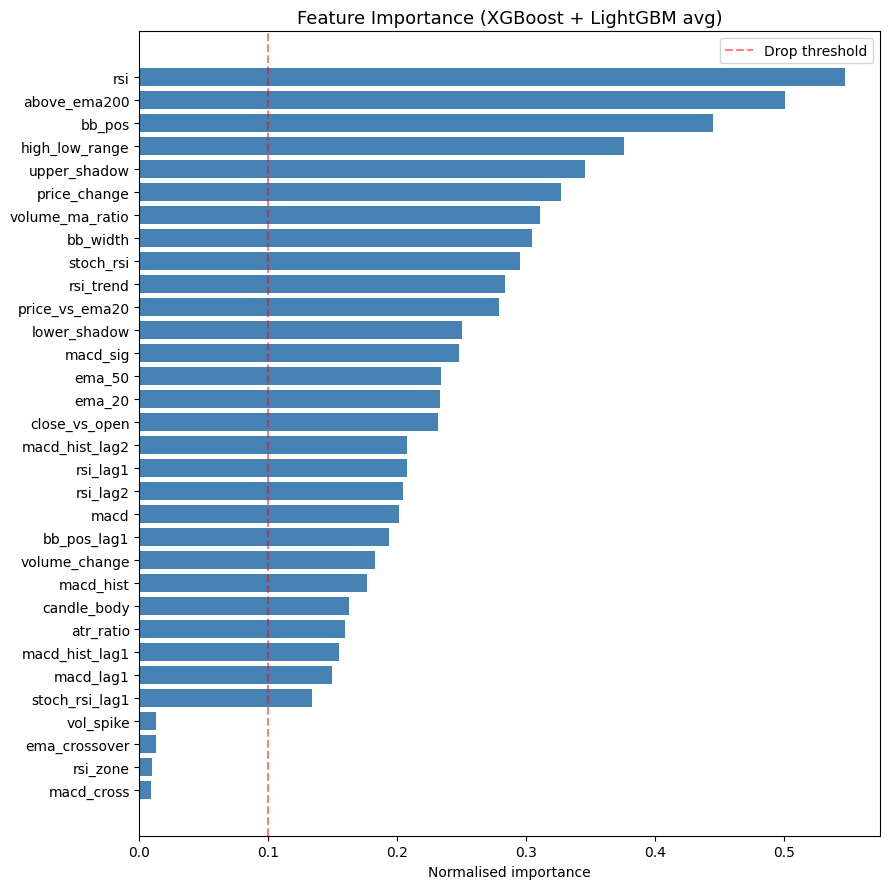

Low-importance features (< 0.10): ['macd_cross', 'rsi_zone', 'ema_crossover', 'vol_spike']


In [10]:
# ── CELL 10: Feature Importance (XGBoost + LightGBM averaged) ─────────────

xgb_imp  = trained['XGBoost'].feature_importances_
lgbm_imp = trained['LightGBM'].feature_importances_

# Normalise both to [0,1] then average
xgb_norm  = xgb_imp  / xgb_imp.max()
lgbm_norm = lgbm_imp / lgbm_imp.max()
avg_imp   = (xgb_norm + lgbm_norm) / 2

imp_df = pd.DataFrame({'feature': features, 'importance': avg_imp})
imp_df = imp_df.sort_values('importance')

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_title('Feature Importance (XGBoost + LightGBM avg)', fontsize=13)
ax.set_xlabel('Normalised importance')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='Drop threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Features to consider dropping
drop_candidates = imp_df[imp_df['importance'] < 0.10]['feature'].tolist()
print(f'Low-importance features (< 0.10): {drop_candidates}')

In [11]:
# ── CELL 11: Live Signal ──────────────────────────────────────────────────
# Uses soft vote ensemble (most robust for production)

latest_x = X_test[[-1]]

# Collect probs from all base models
live_soft = np.zeros((1, 3))
for name, w in weights.items():
    live_soft += w * trained[name].predict_proba(latest_x)

sell_p, hold_p, buy_p = live_soft[0]
regime = df['above_ema200'].values[-1]

signal = ('BUY'  if buy_p  >= BUY_T_SV else
          'SELL' if sell_p >= SEL_T_SV else
          'HOLD')

# Apply regime filter
if regime == 1 and signal == 'SELL':
    signal = 'HOLD'   # suppress SELL in bull regime
if regime == 0 and signal == 'BUY':
    signal = 'HOLD'   # suppress BUY in bear regime

emoji = {'BUY': '🟢', 'SELL': '🔴', 'HOLD': '🟡'}

print(f'{emoji[signal]} Signal  : {signal}')
print(f'   BUY   : {buy_p:.3f}')
print(f'   HOLD  : {hold_p:.3f}')
print(f'   SELL  : {sell_p:.3f}')
print(f'   Regime: {"BULL" if regime else "BEAR"} (above_ema200={regime})')
print(f'   Models: {len(trained)} base models, weighted soft vote')

🟡 Signal  : HOLD
   BUY   : 0.570
   HOLD  : 0.280
   SELL  : 0.150
   Regime: BEAR (above_ema200=0)
   Models: 5 base models, weighted soft vote
